Adatok beolvasása:

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_data

df = load_data()
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Számoszlopok összefoglalója:

In [2]:
df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


Célváltozó(G3) eloszlása:

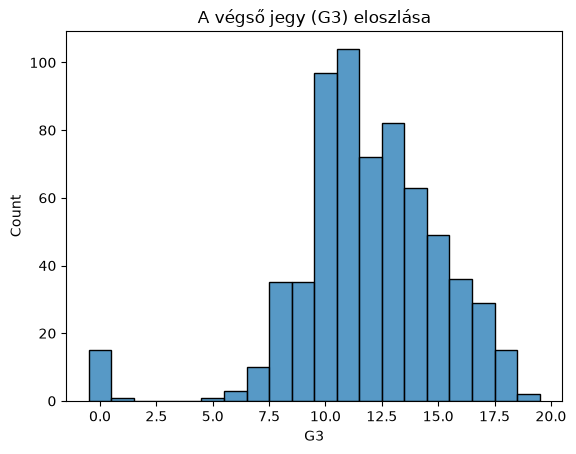

G3 = 0 jegyű diákok száma: 15


In [7]:
sns.histplot(df["G3"], discrete=True)
plt.title("A végső jegy (G3) eloszlása")
plt.show()

print("G3 = 0 jegyű diákok száma:", (df["G3"] == 0).sum())

Az alkoholfogyasztás és a végső jegy kapcsolata:

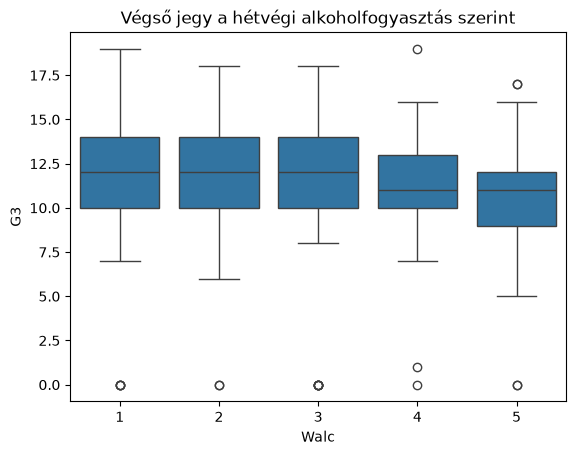

,count,mean
Walc,,
1,247,12.36
2,150,12.26
3,120,11.67
4,87,11.03
5,45,10.56


In [4]:
sns.boxplot(data=df, x="Walc", y="G3")
plt.title("Végső jegy a hétvégi alkoholfogyasztás szerint")
plt.show()

df.groupby("Walc")["G3"].agg(["count", "mean"]).round(2)

Melyik számoszlop függ össze a G3-mal:

In [5]:
num = df.select_dtypes("number")
num.corr()["G3"].drop("G3").sort_values()

failures     -0.393316
Dalc         -0.204719
Walc         -0.176619
traveltime   -0.127173
freetime     -0.122705
age          -0.106505
health       -0.098851
absences     -0.091379
goout        -0.087641
famrel        0.063361
Fedu          0.211800
Medu          0.240151
studytime     0.249789
G1            0.826387
G2            0.918548
Name: G3, dtype: float64

A szöveges oszlopok kategóriái:

In [6]:
for col in df.select_dtypes(exclude="number").columns:
    print(col, df[col].value_counts().to_dict())

school {'GP': 423, 'MS': 226}
sex {'F': 383, 'M': 266}
address {'U': 452, 'R': 197}
famsize {'GT3': 457, 'LE3': 192}
Pstatus {'T': 569, 'A': 80}
Mjob {'other': 258, 'services': 136, 'at_home': 135, 'teacher': 72, 'health': 48}
Fjob {'other': 367, 'services': 181, 'at_home': 42, 'teacher': 36, 'health': 23}
reason {'course': 285, 'home': 149, 'reputation': 143, 'other': 72}
guardian {'mother': 455, 'father': 153, 'other': 41}
schoolsup {'no': 581, 'yes': 68}
famsup {'yes': 398, 'no': 251}
paid {'no': 610, 'yes': 39}
activities {'no': 334, 'yes': 315}
nursery {'yes': 521, 'no': 128}
higher {'yes': 580, 'no': 69}
internet {'yes': 498, 'no': 151}
romantic {'no': 410, 'yes': 239}
